**Проверяемая гипотеза:** Средняя цена за кв.м. зависит от количества станций метро поблизости к дому

**H0:** Квартиры с тремя по близости станциями метро имеют примерно ту же среднюю стоимость за кв.м.,  что и квартиры с менее  чем 3 станций метро

**H1:** Квартиры с тремя по близости станциями метро имеют отличную среднюю стоимость за кв.м. от квартир с менее  чем 3 станций метро

В качестве статистического критерия выбрал `t-тест`, потому что:

*   Проверяю две независимые группы (выборки) на равенство средних
*   T-тест имеет поправку Уэлча, которая позволяет производить более точные вычисления при неравенстве дисперсий





Результаты t-теста:
*  `t_stat = 49`
*   `p-value = 0`
* Уровень значимости `α = 0.05`


Визуализация средних цен за кв.м. по группам:

* Группа (0-2) - от ни одной до двух станций метро вблизи квартиры
* Группа (3) - ровно три станции метро по близости

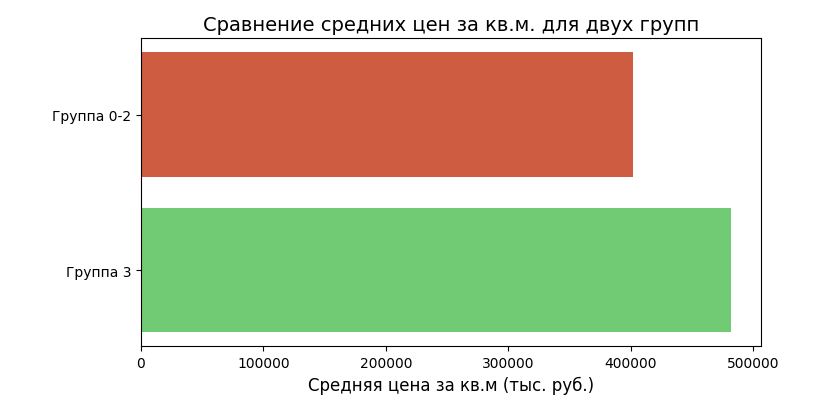

ВЫВОД

**НУЛЕВАЯ ГИПОТЕЗА ОТКЛОНЯЕТСЯ**, так как:
*   `t_stat > |3|` означает, что различия в средней цене за квадратный метр для квартир с тремя станциями метро по близости и с менее тремя станциями статистически различимо.
*   Значение `p-value` в районе нуля означает, что вероятность случайно получить различия в цене практически невозможно.





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('df_after_eda.csv', low_memory=False)

In [135]:
hdf = df[['price','stations_nearby','total_area']].copy()
hdf['price_per_m2'] = hdf['price'] / hdf['total_area']  # новая фича - цена за кв.м
hdf['is_three_st_nearby'] = hdf['stations_nearby'] == 3 # новая фича - True для 3-х станций по близости, иначе (0-2) --> False

In [136]:
group_eq_three = hdf[hdf['is_three_st_nearby'] == True]['price_per_m2']
group_less_than_three = hdf[hdf['is_three_st_nearby'] == False]['price_per_m2']

#group_less_than_three = hdf_not_true_only['price_per_m2']
#group_eq_three = hdf_true_only['price_per_m2']

print(f"Размеры выборок для групп:\nГруппа (0-2): {group_less_than_three.shape[0]} записей\nГруппа (3): {group_eq_three.shape[0]} записей")

Размеры выборок для групп:
Группа (0-2): 9281 записей
Группа (3): 18904 записей


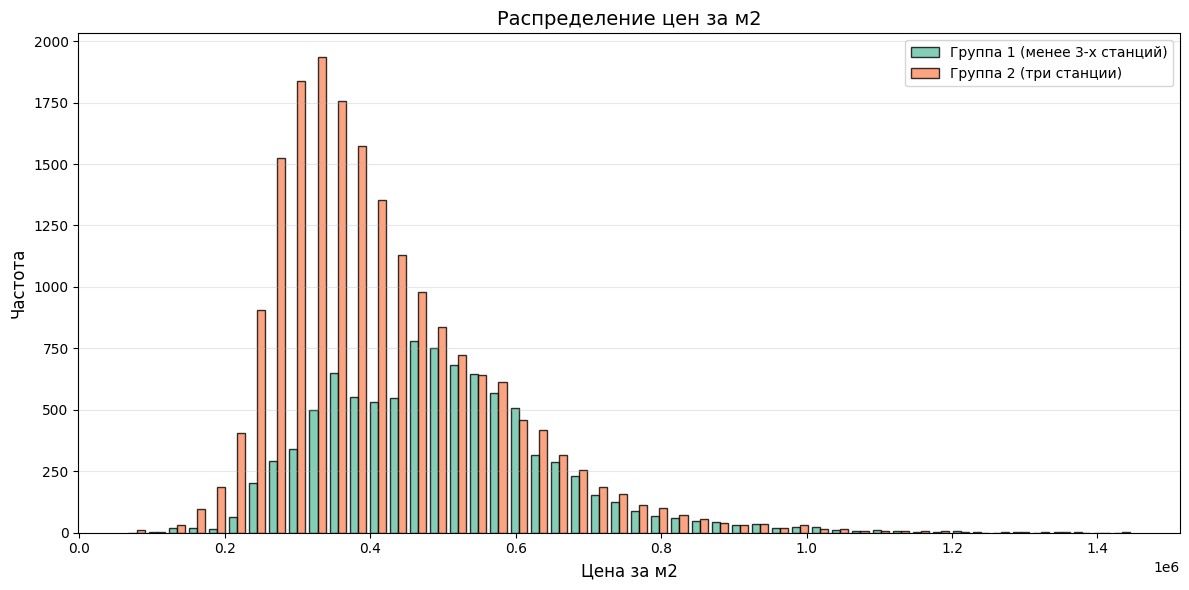

In [137]:
import seaborn as sns
sns.set_palette("Set2")

plt.figure(figsize=(12, 6))

bins = np.histogram_bin_edges(
    np.concatenate([group_less_than_three, group_eq_three]),
    bins=50
)

plt.hist([group_less_than_three, group_eq_three],
         bins=bins,
         edgecolor='black',
         alpha=0.8,
         label=['Группа 1 (менее 3-х станций)', 'Группа 2 (три станции)'],
         histtype='bar',
         rwidth=0.8)

plt.title('Распределение цен за м2', fontsize = 14)
plt.xlabel('Цена за м2', fontsize = 12)
plt.ylabel('Частота', fontsize = 12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Проверим на наличие нормального распределения в группах при помощи теста Колмогорова-Смирнова

In [138]:
from scipy.stats import kstest, norm

def normalize(df):
  """
  Функция для нормализации цен в датасете
  """

  data = df.copy()
  normalized_data = ((data - data.mean()) / data.std())

  return normalized_data

group_less_than_three_normalized = normalize(group_less_than_three)
group_eq_three_normalized = normalize(group_eq_three)

dstat_less_than_three, p_value_less_than_three = kstest(group_less_than_three_normalized,'norm')
dstat_eq_three, p_value_eq_three = kstest(group_eq_three_normalized,'norm')

report = f"""Результаты теста Колмогорова-Смирнова на нормальность распределения данных в группах.

Для группы 0-2 станции метро по близости к дому:
- Значение p-value : {p_value_less_than_three},
- Значение D-статистики: {dstat_less_than_three:.4f}

Для группы 3 станции метро по близости к дому:
- Значение p-value: {p_value_eq_three}
- Значение D-статистики: {dstat_eq_three:.4f}"""

print(report)

Результаты теста Колмогорова-Смирнова на нормальность распределения данных в группах.

Для группы 0-2 станции метро по близости к дому:
- Значение p-value : 4.185046102846704e-15,
- Значение D-статистики: 0.0426

Для группы 3 станции метро по близости к дому:
- Значение p-value: 6.050383397637793e-158
- Значение D-статистики: 0.0978


**Интерпретация** теста Колмогорова-Смирнова: нулевая гипотеза о том, что данные подвергаются **нормальному закону распределения** для двух групп **отклоняется**, так как значение `p-value ≈ 0`

Также, значение `D-стат. = 0.04` для группы (0-2) говорит о наблюдаемых отклонений от нормального закона распределения. Для группы (3) это отклонение ещё сильнее.

Построим боксплоты для распределения средних цен за кв.м. для групп

/tmp/ipykernel_28543/3770343392.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(group_less_than_three, labels=['Группа 1 (0-2 станции)'],
/tmp/ipykernel_28543/3770343392.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(group_eq_three, labels=['Группа 2 (3 станции)'],


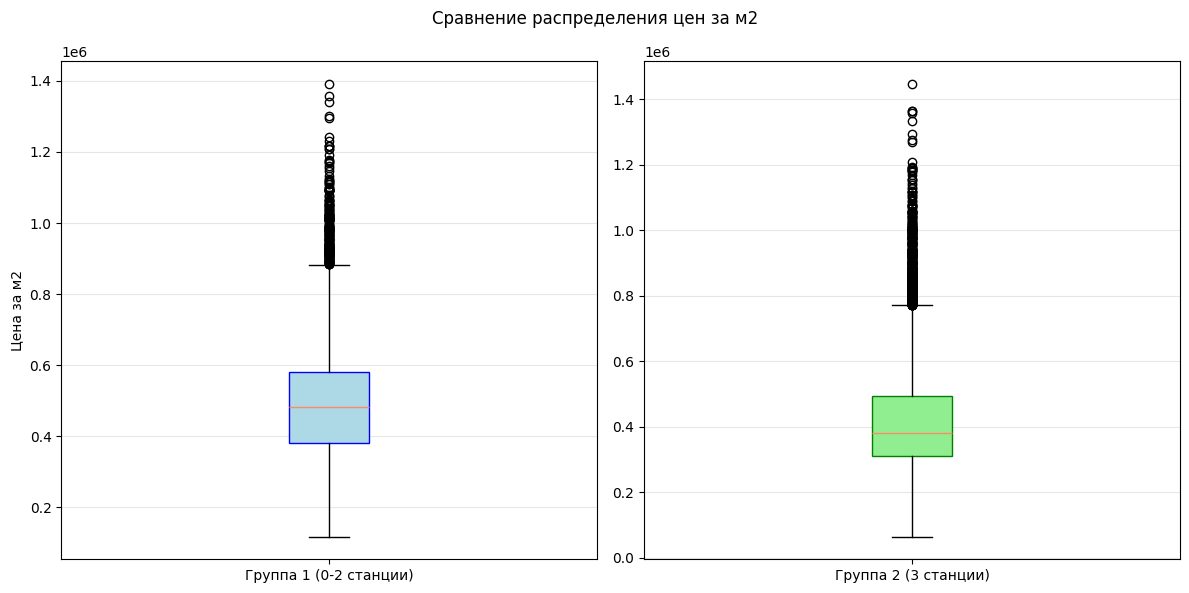

In [139]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(group_less_than_three, labels=['Группа 1 (0-2 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'))
ax2.boxplot(group_eq_three, labels=['Группа 2 (3 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightgreen', color='green'))

ax1.set_ylabel('Цена за м2')
ax1.grid(axis='y', alpha=0.3)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение распределения цен за м2')
plt.tight_layout()
plt.show()

Как можно заметить по графикам - наблюдаются выбросы по цене для каждой из групп, которые необходимо обработать для корректного использования статистического критерия, который чувствителен к этим выбросам.

Для обработки я воспользуюсь методом IQR и срезом через 1 и 99 процентиль

In [140]:
def processing_outliers_iqr(df):
    """Обработка выбросов по IQR"""

    data = df.copy()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5

    non_outliers_mask = (data >= lower_bound) & (data <= upper_bound)

    data_wo_outliers = data[non_outliers_mask]

    return data_wo_outliers

def processing_outliers_percentile(df, lower_percentile : int = 1, upper_percentile : int = 99):
    """Обработка выбросов по заданном процентилям нижней и верхней границы"""

    data = df.copy()
    lower_bound = data.quantile(lower_percentile / 100)
    upper_bound = data.quantile(upper_percentile / 100)

    data_wo_outliers = data[(data >= lower_bound) & (data <= upper_bound)]

    return data_wo_outliers

iqr_df_less_than_three = processing_outliers_iqr(group_less_than_three)
iqr_df_eq_three = processing_outliers_iqr(group_eq_three)

percentile_df_less_than_three = processing_outliers_percentile(iqr_df_less_than_three)
percentile_df_eq_three = processing_outliers_percentile(iqr_df_eq_three)

report = f"""Выборка до/после обработки выбросов (группа 0-2) из {group_less_than_three.shape[0]}/{percentile_df_less_than_three.shape[0]} записей
Процент затёртых данных: {((1 - (percentile_df_less_than_three.shape[0]/ group_less_than_three.shape[0])))*100:.1f}%

Выборка до/после обработки выбросов обработки (группа 3) из {group_eq_three.shape[0]}/{percentile_df_eq_three.shape[0]} записей
Процент затёртых данных: {((1 - (percentile_df_eq_three.shape[0]/ group_eq_three.shape[0])))*100:.1f}%
"""

print(report)

Выборка до/после обработки выбросов (группа 0-2) из 9281/8895 записей
Процент затёртых данных: 4.2%

Выборка до/после обработки выбросов обработки (группа 3) из 18904/18030 записей
Процент затёртых данных: 4.6%



После обработки выбросов `по IQR совместно и срезом по 1 и 99 процентилем` - визуализируем боксплоты распределения средних цен за кв.м.

/tmp/ipykernel_28543/99908006.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(percentile_df_less_than_three, labels=['Группа 1 (0-2 станции)'],
/tmp/ipykernel_28543/99908006.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(percentile_df_eq_three, labels=['Группа 2 (3 станции)'],


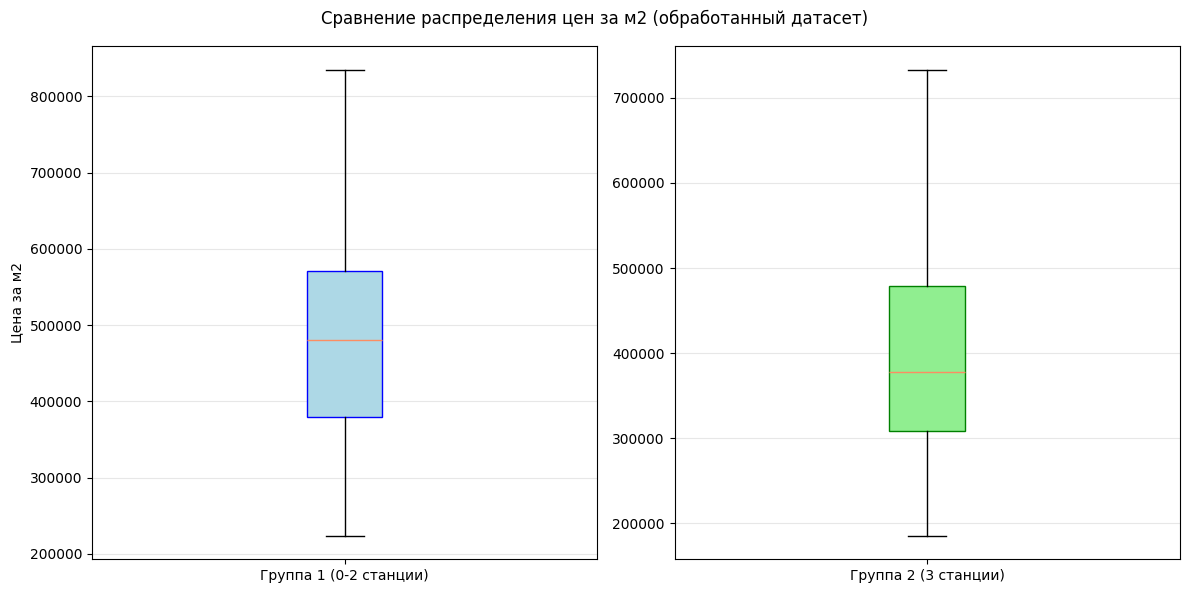

In [141]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(percentile_df_less_than_three, labels=['Группа 1 (0-2 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'))
ax2.boxplot(percentile_df_eq_three, labels=['Группа 2 (3 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightgreen', color='green'))

ax1.set_ylabel('Цена за м2')
ax1.grid(axis='y', alpha=0.3)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение распределения цен за м2 (обработанный датасет)')
plt.tight_layout()
plt.show()

После того, как выбросы обработаны - можно приступать к использованию `t-теста`.

Но перед этим проиллюстрирую средние цены за кв.м. для каждой из группы

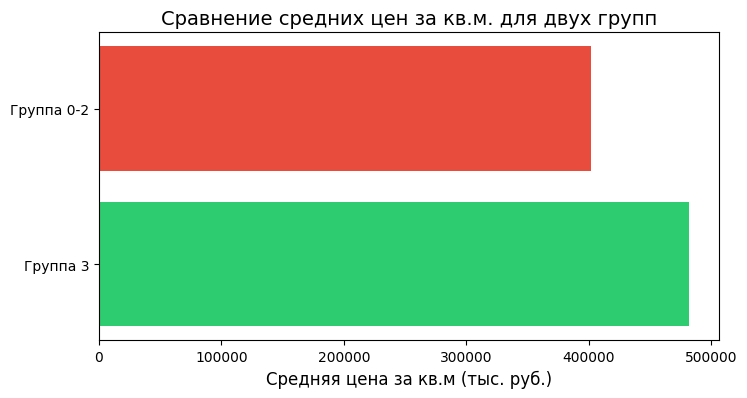

In [142]:
price_per_m2_3 = percentile_df_less_than_three.mean()
price_per_m2_0_2 = percentile_df_eq_three.mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['Группа 3','Группа 0-2'],
               [price_per_m2_3, price_per_m2_0_2],
               color=['#2ecc71', '#e74c3c'])

plt.title('Сравнение средних цен за кв.м. для двух групп', fontsize = 14)
plt.xlabel('Средняя цена за кв.м (тыс. руб.)', fontsize = 12)
plt.show()

Невооружённым глазом можно заметить, что разница средних за квадратный метр для двух групп присутствует.

Проверить, является ли статистически значимой разница средних поможет `t-тест` с поправкой Уэлча (`equal_var = False`).

In [143]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(percentile_df_less_than_three, percentile_df_eq_three, equal_var=False)
print(f"Значение t_stat: {t_stat:.4f} и p-value: {p_value:.5f}")

Значение t_stat: 49.0356 и p-value: 0.00000


**ИНТЕРПРЕТАЦИЯ**:
*   `t_stat > |3|` означает, что различия в средней цене за квадратный метр для квартир с тремя станциями метро по близости и с менее тремя станциями статистически различимо.
*   Значение `p-value` в районе нуля означает, что вероятность случайно получить различия в цене практически невозможно.

**НУЛЕВАЯ ГИПОТЕЗА ОТКЛОНЯЕТСЯ**